In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

root_dir = current_dir
while not (root_dir / 'utils').is_dir() and root_dir != root_dir.parent:
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

In [2]:
import numpy as np
import pandas as pd
from collections import Counter
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from utils.custom_hyperparameter_tunning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from sklearn.utils import resample
from utils.model_manager import save_model_package

In [ ]:
class LinearSVMScratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=100):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        if hasattr(X, "toarray"): 
            X = X.toarray()
        elif hasattr(X, "values"): 
            X = X.values
        else: 
            X = np.array(X)
            
        if hasattr(y, "values"): 
            y = y.values
        else: 
            y = np.array(y)

        n_samples, n_features = X.shape
        
        y_ = np.where(y <= 0, -1, 1)
        
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.learning_rate * y_[idx]

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        elif hasattr(X, "values"): X = X.values
        else: X = np.array(X)
        
        approx = np.dot(X, self.w) - self.b
        
        return np.where(np.sign(approx) == -1, 0, 1)

    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "lambda_param": self.lambda_param,
            "n_iters": self.n_iters
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

In [4]:
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

In [5]:
X_train_sub_sparse, y_train_sub_raw = resample(
    X_train, y_train, 
    n_samples=3000, 
    random_state=42, 
    stratify=y_train 
)
X_train_sub = X_train_sub_sparse.toarray()
y_train_sub = np.array(y_train_sub_raw)

In [6]:
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

svm_scratch = LinearSVMScratch()

param_grid_svm = {
    'learning_rate': [0.01, 0.001],
    'lambda_param': [0.01, 0.001],
    'n_iters': [50]
}

grid_search_svm = CustomGridSearchCV(estimator=svm_scratch, param_grid=param_grid_svm, cv=cv)
grid_search_svm.fit(X_train_sub, y_train_sub)

Bắt đầu GridSearchCV: Sẽ chạy 4 tổ hợp tham số, mỗi tổ hợp 3 folds.
Tổng cộng số lần huấn luyện: 12 lần.

[1/4] Tham số: {'learning_rate': 0.01, 'lambda_param': 0.01, 'n_iters': 50} --> R2 trung bình: 0.7969
[2/4] Tham số: {'learning_rate': 0.01, 'lambda_param': 0.001, 'n_iters': 50} --> R2 trung bình: 0.9025
[3/4] Tham số: {'learning_rate': 0.001, 'lambda_param': 0.01, 'n_iters': 50} --> R2 trung bình: 0.8557
[4/4] Tham số: {'learning_rate': 0.001, 'lambda_param': 0.001, 'n_iters': 50} --> R2 trung bình: 0.8677
Tham số TỐT NHẤT: {'learning_rate': 0.01, 'lambda_param': 0.001, 'n_iters': 50}
R2 CV TỐT NHẤT  : 0.9025


In [7]:
best_params_svm = grid_search_svm.best_params_
print(f"Tham số SVM tốt nhất: {best_params_svm}")

final_svm = LinearSVMScratch(
    learning_rate=best_params_svm['learning_rate'],
    lambda_param=best_params_svm['lambda_param'],
    n_iters=150 
)

Tham số SVM tốt nhất: {'learning_rate': 0.01, 'lambda_param': 0.001, 'n_iters': 50}


In [8]:
final_svm.fit(X_train_sub, y_train_sub)

In [9]:
y_pred_svm = final_svm.predict(X_test)

In [ ]:
metrics_svm = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1_Score': f1_score(y_test, y_pred_svm)
}
print(f"Precision : {metrics_svm['Precision']:.4f}")
print(f"Accuracy  : {metrics_svm['Accuracy']:.4f}")
print(f"Recall    : {metrics_svm['Recall']:.4f}")
print(f"F1 Score  : {metrics_svm['F1_Score']:.4f}")


--- KẾT QUẢ SVM (SCRATCH) ---
Precision (Rất quan trọng): 0.9420
F1 Score : 0.9662


In [19]:
save_model_package(
    model=final_svm,                                  
    model_name="SVM Linear Scratch",    
    best_params={'learning_rate': 0.01, 'lambda_param': 0.001, 'n_iters': 50},
    metrics=metrics_svm
)

'models\\SVM_Linear_Scratch.pkl'

In [12]:
from sklearn.svm import LinearSVC

--- 1. CHUẨN BỊ MÔ HÌNH SVM TỪ SCIKIT-LEARN ---
Đang chạy Grid Search cho Scikit-learn LinearSVC (Trên toàn bộ dữ liệu)...
Bắt đầu GridSearchCV: Sẽ chạy 3 tổ hợp tham số, mỗi tổ hợp 3 folds.
Tổng cộng số lần huấn luyện: 9 lần.

[1/3] Tham số: {'C': 0.1, 'max_iter': 1000} --> R2 trung bình: 0.9316
[2/3] Tham số: {'C': 1, 'max_iter': 1000} --> R2 trung bình: 0.9397
[3/3] Tham số: {'C': 10, 'max_iter': 1000} --> R2 trung bình: 0.9157
Tham số TỐT NHẤT: {'C': 1, 'max_iter': 1000}
R2 CV TỐT NHẤT  : 0.9397
Tham số tốt nhất của LinearSVC: {'C': 1, 'max_iter': 1000}

--- 2. ĐÁNH GIÁ TRÊN TẬP TEST (ĐỐI CHIẾU KẾT QUẢ) ---
Accuracy : 0.9833
Precision: 0.9766 (Chỉ số sát thủ bắt Spam)
Recall   : 0.9887
F1 Score : 0.9826


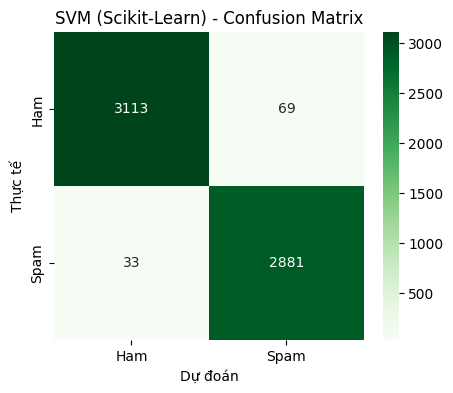

In [ ]:
import joblib
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

X_train_full = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test_full = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train_full = joblib.load('./data/ready_for_train/y_train.pkl').values
y_test_full = joblib.load('./data/ready_for_train/y_test.pkl').values

svc_model = LinearSVC(random_state=42, dual=False)

param_grid_svc = {
    'C': [0.1, 1, 10], 
    'max_iter': [1000]
}

grid_search_svc = CustomGridSearchCV(estimator=svc_model, param_grid=param_grid_svc, cv=cv)

grid_search_svc.fit(X_train_full, y_train_full)

best_svc_model = grid_search_svc.best_estimator_
best_params_svc = grid_search_svc.best_params_
print(f"Tham số tốt nhất của LinearSVC: {best_params_svc}")

y_pred_sklearn = best_svc_model.predict(X_test_full)

acc_sk = accuracy_score(y_test_full, y_pred_sklearn)
prec_sk = precision_score(y_test_full, y_pred_sklearn)
rec_sk = recall_score(y_test_full, y_pred_sklearn)
f1_sk = f1_score(y_test_full, y_pred_sklearn)

print(f"Accuracy : {acc_sk:.4f}")
print(f"Precision: {prec_sk:.4f}")
print(f"Recall   : {rec_sk:.4f}")
print(f"F1 Score : {f1_sk:.4f}")

cm_sk = confusion_matrix(y_test_full, y_pred_sklearn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('SVM (Scikit-Learn) - Confusion Matrix')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()